### OUR GOAL here is...
#### Not to reduce the Error, increase the Error slightly

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# Load dataset
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Take 350 observations
X = X.head(350)
y = y[:350]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1,)

# Train models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
elastic_model.fit(X_train, y_train)

# Print coefficients
print("Linear Regression Coefficients")
print(rolinear_model.coef_)

print("Ridge Regression Coefficients")
print(ridge_model.coef_)

print("Lasso Regression Coefficients")
print(lasso_model.coef_)

print("Elastic Net Coefficients")
print(elastic_model.coef_)

Linear Regression Coefficients
[ 3.03732127e-01 -3.92677588e-03 -2.89743662e-02 -7.96409416e-01
  9.54167748e-05 -6.44282585e-02  1.24547352e+01  2.99640816e+00]
Ridge Regression Coefficients
[ 3.88603052e-01 -1.97759365e-03 -4.22854574e-02 -7.36955210e-01
  1.00208090e-04 -1.41228031e-01  1.37512770e+00 -1.04863384e+00]
Lasso Regression Coefficients
[ 3.56625622e-01 -2.02258013e-03 -0.00000000e+00 -0.00000000e+00
  1.19436374e-04 -4.87440503e-02  0.00000000e+00 -0.00000000e+00]
Elastic Net Coefficients
[ 3.62461441e-01 -2.00428925e-03 -0.00000000e+00 -0.00000000e+00
  1.13946179e-04 -9.56057216e-02  0.00000000e+00 -0.00000000e+00]


In [8]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
345,1.7120,36.0,6.307229,1.289157,651.0,3.921687,37.75,-122.18
346,2.5625,33.0,4.475524,1.073427,999.0,3.493007,37.76,-122.17
347,1.9821,43.0,5.186275,1.045752,907.0,2.964052,37.75,-122.17
348,2.5043,41.0,5.465217,1.178261,828.0,3.600000,37.75,-122.17


      Feature  Coefficient
3   AveBedrms    -0.796409
5    AveOccup    -0.064428
2    AveRooms    -0.028974
1    HouseAge    -0.003927
4  Population     0.000095
0      MedInc     0.303732
7   Longitude     2.996408
6    Latitude    12.454735


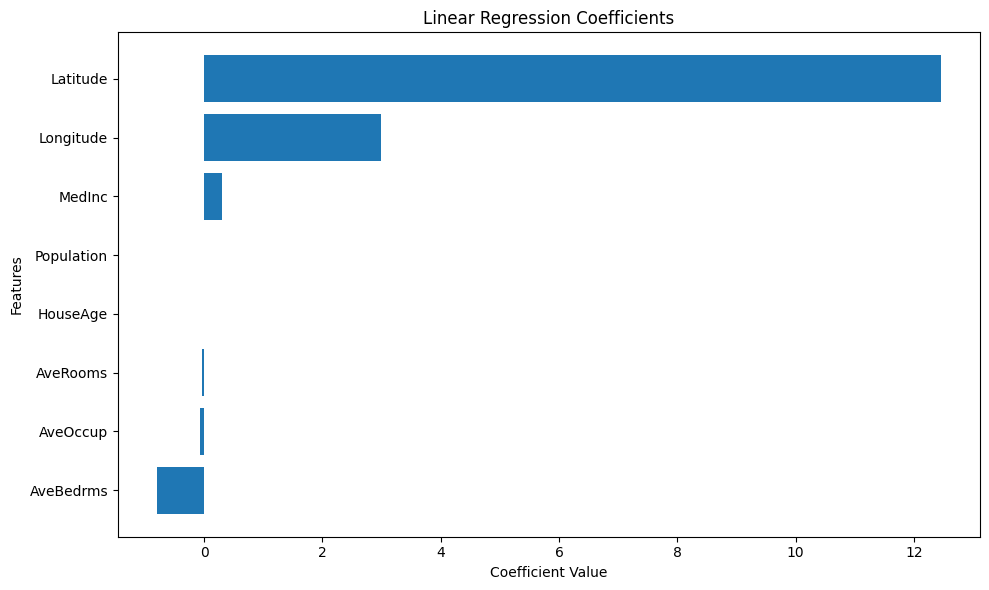

      Feature  Coefficient
7   Longitude    -1.048634
3   AveBedrms    -0.736955
5    AveOccup    -0.141228
2    AveRooms    -0.042285
1    HouseAge    -0.001978
4  Population     0.000100
0      MedInc     0.388603
6    Latitude     1.375128


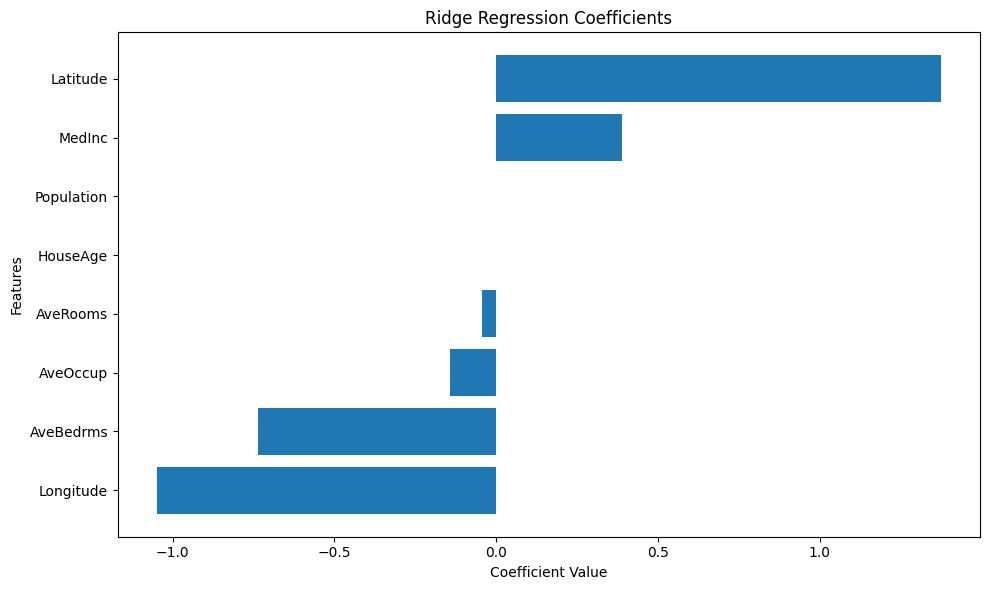

      Feature  Coefficient
5    AveOccup    -0.048744
1    HouseAge    -0.002023
3   AveBedrms    -0.000000
2    AveRooms    -0.000000
7   Longitude    -0.000000
6    Latitude     0.000000
4  Population     0.000119
0      MedInc     0.356626


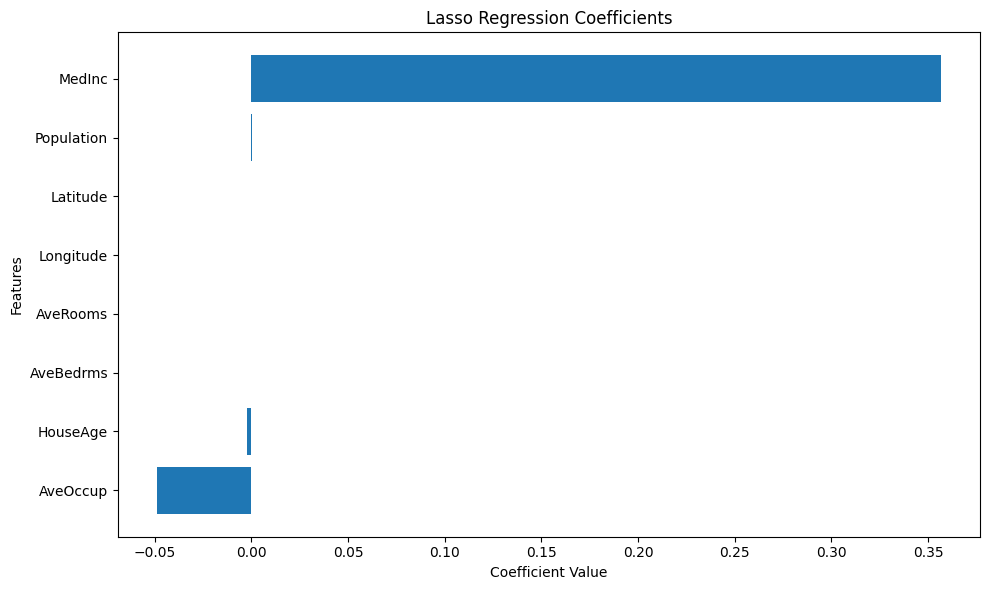

      Feature  Coefficient
5    AveOccup    -0.095606
1    HouseAge    -0.002004
3   AveBedrms    -0.000000
2    AveRooms    -0.000000
7   Longitude    -0.000000
6    Latitude     0.000000
4  Population     0.000114
0      MedInc     0.362461


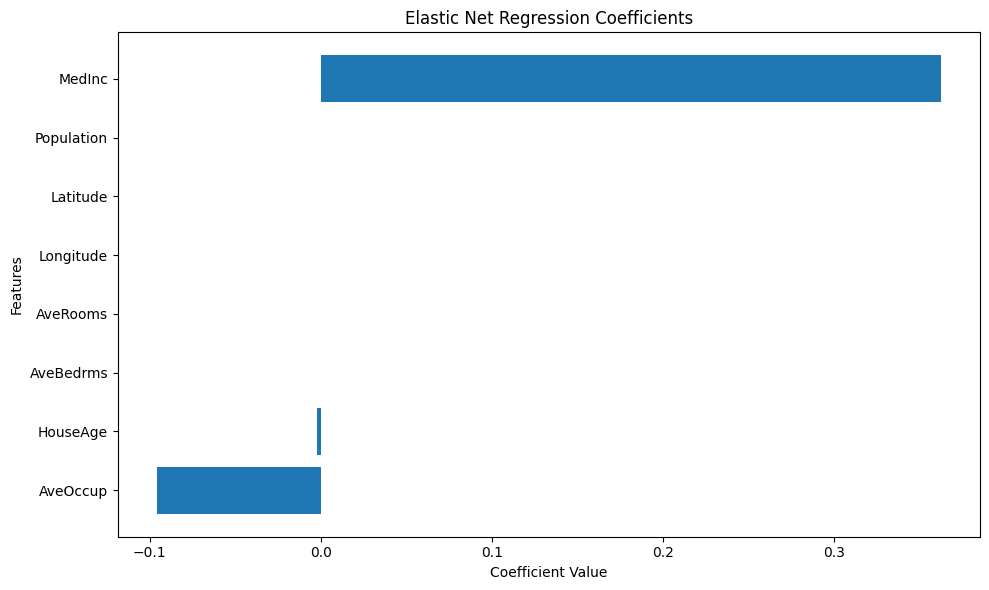

In [14]:
import matplotlib.pyplot as plt

# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()


# Linear Regression
plot_coefficients(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)

# Ridge Regression
plot_coefficients(
    ridge_model,
    X.columns,
    "Ridge Regression Coefficients"
)

# Lasso Regression
plot_coefficients(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)

# Elastic Net
plot_coefficients(
    elastic_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(name)
    print("MSE:", mse)
    print("R2:", r2)
    print()

Linear
MSE: 0.1316027485366282
R2: 0.8116533567039953

Ridge
MSE: 0.1414497153366992
R2: 0.7975606180335383

Lasso
MSE: 0.182429198190486
R2: 0.7389117818554038

ElasticNet
MSE: 0.16930447974293208
R2: 0.7576955587239692



# VERY IMPORTANT POINT TO NOTE:

#### Regularized models may show slightly higher training cost, but they generalize better on unseen data.

# =============================================

## Practice the same Scripting and plot the same graph without looking into scripting.

# THE END!